In [1]:
import os
import mne
import numpy as np
import os.path as op
import matplotlib.pyplot as plt
from mne.preprocessing import (ICA, create_ecg_epochs, annotate_muscle_zscore, annotate_movement, 
                               compute_average_dev_head_t, create_eog_epochs, find_eog_events, find_ecg_events)
from collections import Counter

## Set up path and directory to data cataloging structure

In [2]:
# Set pathway and doucment location
s = 'p030'
v = 'Final'
path = f'/Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro'
meg_dir = op.join(path, f'{s}_MEG_ENS_Gabor')

In [3]:
# Load your raw and empty room MEG data
raw = mne.io.read_raw_fif(op.join(meg_dir, v,f'{s}_GABOR_all_esss.fif'), preload=True)

Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p030_MEG_ENS_Gabor/Final/p030_GABOR_all_esss.fif...
    Range : 364603 ... 1946602 =    364.603 ...  1946.602 secs
Ready.
Opening raw data file /Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p030_MEG_ENS_Gabor/Final/p030_GABOR_all_esss-1.fif...
    Range : 1946603 ... 3494603 =   1946.603 ...  3494.603 secs
Ready.
Reading 0 ... 3130000  =      0.000 ...  3130.000 secs...


/var/folders/wy/8whx0tpj43sgygf2n0g0f5340000gn/T/ipykernel_48586/4113111564.py:2: RuntimeWarning: This filename (/Users/immlab/Desktop/IMM-Lab/Gabor_MEG/Prepro/p030_MEG_ENS_Gabor/Final/p030_GABOR_all_esss.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(op.join(meg_dir, v,f'{s}_GABOR_all_esss.fif'), preload=True)


In [ ]:
# # For Subject p018 Only, becuase the recoding has massive environmental artifacts
# bad_spans_1_onsets = np.array([433, 870.5, 1225.5, 1611.8, 1630.5, 1769.7, 2049, 2511.3])
# bad_spans_2_onsets = np.array([484.8, 993.5, 1051.8, 1135, 1467.6, 1588.8, 1654.7, 1708.3, 2021.5, 2096, 2596.3])

# Bad_span_1sec = mne.Annotations(
#     onset=bad_spans_1_onsets+32, # in seconds
#     duration=1,  # in seconds, too
#     description="Bad span 1 second",
#     orig_time = raw.info['meas_date'])

# Bad_span_2sec = mne.Annotations(
#     onset=bad_spans_2_onsets+32, # in seconds
#     duration=2,  # in seconds, too
#     description="Bad span 2 seconds",
#     orig_time = raw.info['meas_date'])

## Read the event codes and check the triggers

1975 events found on stim channel STI101
Event IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 64]


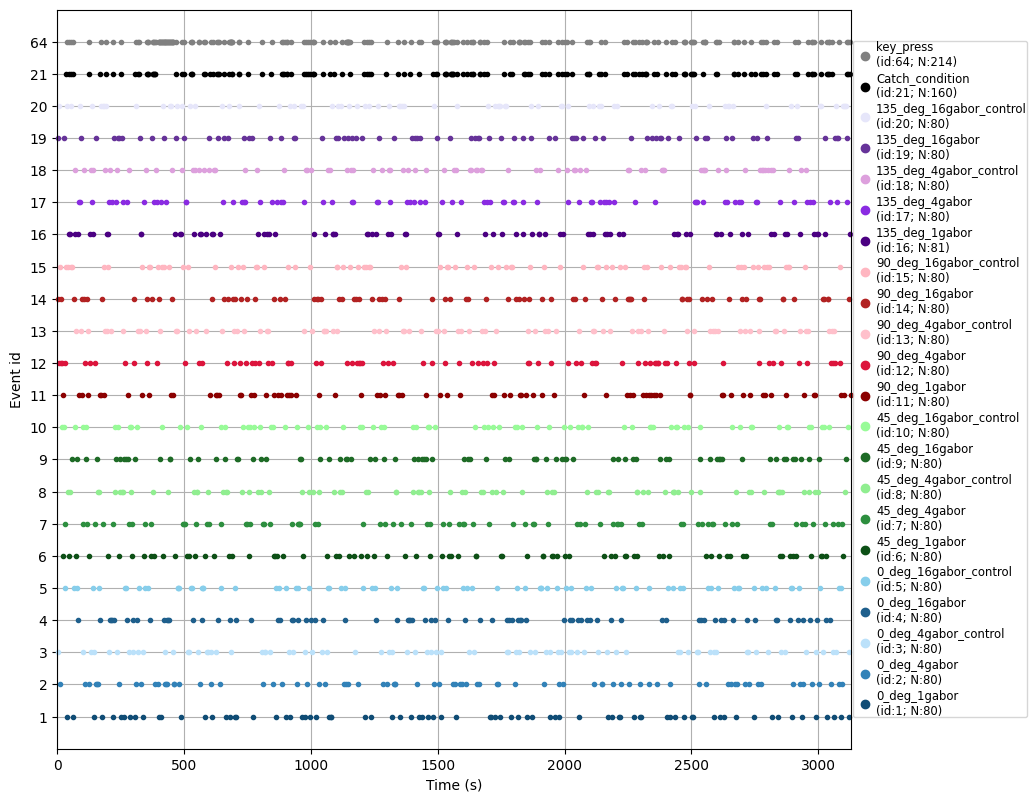

In [4]:
# Find triggers
print("="*60)
events = mne.find_events(raw, stim_channel='STI101', shortest_event=1/raw.info['sfreq']) # raw.info['sfreq']= 1000 Hz

# Create color scheme with similar colors for each orientation group
event_colors = {
    # 0 degree (1-5): Blues
    1: '#0f4c75',    # Dark blue (0_deg_1gabor)
    2: '#3282b8',    # Medium blue (0_deg_4gabor)
    3: '#bbe1fa',    # Light blue (0_deg_4gabor_control)
    4: '#1e5f8c',    # Blue (0_deg_16gabor)
    5: '#87ceeb',    # Sky blue (0_deg_16gabor_control)
    # 45 degree (6-10): Greens
    6: '#0d5016',    # Dark green (45_deg_1gabor)
    7: '#2d8f3f',    # Medium green (45_deg_4gabor)
    8: '#90ee90',    # Light green (45_deg_4gabor_control)
    9: '#1e6b26',    # Green (45_deg_16gabor)
    10: '#98fb98',   # Pale green (45_deg_16gabor_control)
    # 90 degree (11-15): Reds
    11: '#8b0000',   # Dark red (90_deg_1gabor)
    12: '#dc143c',   # Crimson (90_deg_4gabor)
    13: '#ffc0cb',   # Pink (90_deg_4gabor_control)
    14: '#b22222',   # Fire brick (90_deg_16gabor)
    15: '#ffb6c1',   # Light pink (90_deg_16gabor_control)
    # 135 degree (16-20): Purples
    16: '#4b0082',   # Indigo (135_deg_1gabor)
    17: '#8a2be2',   # Blue violet (135_deg_4gabor)
    18: '#dda0dd',   # Plum (135_deg_4gabor_control)
    19: '#663399',   # Purple (135_deg_16gabor)
    20: '#e6e6fa',   # Lavender (135_deg_16gabor_control)
    # Special events
    21: '#000000',   # Black (Catch_condition)
    64: '#808080' }   # Gray (key_press)


# Setting event name
event_id = {'0_deg_1gabor': 1,'0_deg_4gabor': 2,'0_deg_4gabor_control': 3,'0_deg_16gabor': 4,'0_deg_16gabor_control': 5,
    '45_deg_1gabor': 6,'45_deg_4gabor': 7,'45_deg_4gabor_control': 8,'45_deg_16gabor': 9,'45_deg_16gabor_control': 10,
    '90_deg_1gabor': 11,'90_deg_4gabor': 12,'90_deg_4gabor_control': 13,'90_deg_16gabor': 14,'90_deg_16gabor_control': 15,
    '135_deg_1gabor': 16,'135_deg_4gabor': 17,'135_deg_4gabor_control': 18,'135_deg_16gabor': 19,'135_deg_16gabor_control': 20,
    'Catch_condition':21,"key_press": 64}

# Plot triggers (events)
fig = mne.viz.plot_events(events, event_id=event_id, sfreq=raw.info["sfreq"], first_samp=raw.first_samp, color=event_colors)

# Extra triggers removal

In [5]:
print(" Check repeat triggers")
print("="*60)

# Step 1: Identify events with non-zero previous event ID (problematic overlaps) from the second column of array
problematic_events = np.where(events[:, 1] != 0)[0]

if len(problematic_events) > 0:  # we will  get idx from there
    print(f"Found {len(problematic_events)} repeat events:")
    for idx in problematic_events:
        sample, prev_id, curr_id = events[idx]
        print(f"  Row {idx}: Sample {sample}, Previous ID: {prev_id}, Current ID: {curr_id}")

# Step 2: Count occurrences of each event ID
event_ids = events[:, 2]
event_counts = Counter(event_ids)

print(f"\nEvent ID counts:")
for event_id_nums in sorted(event_counts.keys()):
    print(f"  Event ID {event_id_nums}: {event_counts[event_id_nums]} occurrences")

 Check repeat triggers
Found 1 repeat events:
  Row 1650: Sample 2964438, Previous ID: 16, Current ID: 21

Event ID counts:
  Event ID 1: 80 occurrences
  Event ID 2: 80 occurrences
  Event ID 3: 80 occurrences
  Event ID 4: 80 occurrences
  Event ID 5: 80 occurrences
  Event ID 6: 80 occurrences
  Event ID 7: 80 occurrences
  Event ID 8: 80 occurrences
  Event ID 9: 80 occurrences
  Event ID 10: 80 occurrences
  Event ID 11: 80 occurrences
  Event ID 12: 80 occurrences
  Event ID 13: 80 occurrences
  Event ID 14: 80 occurrences
  Event ID 15: 80 occurrences
  Event ID 16: 81 occurrences
  Event ID 17: 80 occurrences
  Event ID 18: 80 occurrences
  Event ID 19: 80 occurrences
  Event ID 20: 80 occurrences
  Event ID 21: 160 occurrences
  Event ID 64: 214 occurrences


In [6]:
# Step 3: Determine expected counts; Use the most common count as expected (mode)
expected_counts = {}
# Regular conditions (1-20): 80 repetitions each
for event_id_num  in range(1, 21):
    expected_counts[event_id_num ] = 80

# Catch condition (21): 160 repetitions
expected_counts[21] = 160

# Key press (64): variable, don't clean
# We'll handle this separately by excluding it from cleaning
print(f"\nExpected events count:")
print(f"  Event IDs 1-20: 80 repetitions each")
print(f"  Event ID 21 (catch): 160 repetitions")
print(f"  Event ID 64 (key press): variable (no cleaning)")
print(f"  Other event IDs: will be flagged as unexpected")


Expected events count:
  Event IDs 1-20: 80 repetitions each
  Event ID 21 (catch): 160 repetitions
  Event ID 64 (key press): variable (no cleaning)
  Other event IDs: will be flagged as unexpected


In [7]:
# Step 4: Identify conditions with extra triggers
indices_to_remove = []

# Sort by event_id for cleaner output
for event_id_num in sorted(event_counts.keys()):
    count = event_counts[event_id_num]
    # Skip key_press events; they are dependent variable.
    if event_id_num == 64:
        print(f"Event ID {event_id_num} (key_press): {count} occurrences - SKIPPING (not experimental condition)")
        continue
    
    # Check if this event ID is expected (1-21, and 64)
    if event_id_num not in expected_counts:
        print(f"\nUnexpected Event ID {event_id_num}: {count} occurrences - will be flagged")
        # You can choose to remove all unexpected events or just flag them
        # For now, let's just flag them but not auto-remove
        continue

    target_count = expected_counts[event_id_num]
    if count > target_count:
        print(f"\nEvent ID {event_id_num} has {count} triggers (expected {target_count})")
        
        # Find all occurrences of this event ID
        event_positions = np.where(events[:, 2] == event_id_num)[0]
        
        # Strategy: Find triggers that caused overlaps (the ones BEFORE non-zero previous IDs)
        problematic_triggers_for_this_event = []
        
        # Look for events where this event_id appears as previous_id in the next event
        for i in range(len(events) - 1):  # Check all events except the last one
            current_event_id = events[i, 2]  # Current event's ID
            next_prev_id = events[i + 1, 1]  # Next event's previous ID
            
            # If current event is our target event_id AND it shows up as previous_id in next event
            if current_event_id == event_id_num and next_prev_id == event_id_num:
                problematic_triggers_for_this_event.append(i)
                print(f"    Found problematic trigger at row {i}: caused overlap detected at row {i+1}")
        
        # Remove the required number of problematic triggers
        excess_count = count - target_count
        
        if len(problematic_triggers_for_this_event) >= excess_count:
            # Remove only the needed number of problematic triggers
            indices_to_remove.extend(problematic_triggers_for_this_event[:excess_count])
            print(f"  Removing {excess_count} problematic triggers for event ID {event_id_num}")
            print(f"  Removed rows: {problematic_triggers_for_this_event[:excess_count]}")
        else:
            # If not enough problematic triggers identified, remove all problematic ones
            # and then remove additional ones from the end
            indices_to_remove.extend(problematic_triggers_for_this_event)
            remaining_to_remove = excess_count - len(problematic_triggers_for_this_event)
            
            # Remove additional triggers from the end (most recent ones)
            regular_events = [pos for pos in event_positions if pos not in problematic_triggers_for_this_event]
            indices_to_remove.extend(regular_events[-remaining_to_remove:])
            
            print(f"  Removing {len(problematic_triggers_for_this_event)} problematic + {remaining_to_remove} regular triggers")
            print(f"  Problematic rows removed: {problematic_triggers_for_this_event}")
            print(f"  Regular rows removed: {regular_events[-remaining_to_remove:]}")
    
    elif count < target_count:
        print(f"\nEvent ID {event_id_num} has {count} triggers (expected {target_count}) - MISSING TRIGGERS!")

# Step 5: Remove identified problematic events
events_cleaned = np.delete(events, indices_to_remove, axis=0)

print(f"\nSUMMARY:")
print(f"  Original events: {len(events)}")
print(f"  Removed events: {len(indices_to_remove)}")
print(f"  Final events: {len(events_cleaned)}")
    
if len(indices_to_remove) > 0:
     print(f"  All removed rows: {sorted(indices_to_remove)}")

# Verify the cleaning worked
print(f"\nVERIFICATION - Event counts after cleaning:")
cleaned_event_ids = events_cleaned[:, 2]
cleaned_event_counts = Counter(cleaned_event_ids)

for event_id_num in sorted(cleaned_event_counts.keys()):
    count = cleaned_event_counts[event_id_num]
    if event_id_num in expected_counts:
        expected = expected_counts[event_id_num]
        status = "✓" if count == expected else "✗"
        print(f"  Event ID {event_id_num}: {count} occurrences (expected {expected}) {status}")
    else:
        print(f"  Event ID {event_id_num}: {count} occurrences (unexpected)")
        
events = events_cleaned


Event ID 16 has 81 triggers (expected 80)
    Found problematic trigger at row 1649: caused overlap detected at row 1650
  Removing 1 problematic triggers for event ID 16
  Removed rows: [1649]
Event ID 64 (key_press): 214 occurrences - SKIPPING (not experimental condition)

SUMMARY:
  Original events: 1975
  Removed events: 1
  Final events: 1974
  All removed rows: [1649]

VERIFICATION - Event counts after cleaning:
  Event ID 1: 80 occurrences (expected 80) ✓
  Event ID 2: 80 occurrences (expected 80) ✓
  Event ID 3: 80 occurrences (expected 80) ✓
  Event ID 4: 80 occurrences (expected 80) ✓
  Event ID 5: 80 occurrences (expected 80) ✓
  Event ID 6: 80 occurrences (expected 80) ✓
  Event ID 7: 80 occurrences (expected 80) ✓
  Event ID 8: 80 occurrences (expected 80) ✓
  Event ID 9: 80 occurrences (expected 80) ✓
  Event ID 10: 80 occurrences (expected 80) ✓
  Event ID 11: 80 occurrences (expected 80) ✓
  Event ID 12: 80 occurrences (expected 80) ✓
  Event ID 13: 80 occurrences (exp

In [ ]:
# # For P008 Only
# # Find triggers
# events = mne.find_events(raw, stim_channel='STI101', shortest_event=1/raw.info['sfreq'])

# # Setting event name
# event_id = {'0_deg_1gabor': 64,'0_deg_4gabor': 32,'0_deg_4gabor_control': 96,'0_deg_16gabor': 16,'0_deg_16gabor_control': 80,
#     '45_deg_1gabor': 48,'45_deg_4gabor': 112,'45_deg_4gabor_control': 8,'45_deg_16gabor': 72,'45_deg_16gabor_control': 40,
#     '90_deg_1gabor': 104,'90_deg_4gabor': 24,'90_deg_4gabor_control': 88,'90_deg_16gabor': 56,'90_deg_16gabor_control': 120,
#     '135_deg_1gabor': 4,'135_deg_4gabor': 68,'135_deg_4gabor_control': 36,'135_deg_16gabor': 100,'135_deg_16gabor_control': 20, 'Catch_condition':84,
#     'key_press': 1}

# # Plot triggers (events)
# fig = mne.viz.plot_events(events, event_id=event_id, sfreq=raw.info["sfreq"], first_samp=raw.first_samp)

## Detect artifacts, like Eye movement/blink (EOG), Heart beat (ECG)

Using EOG channels: EOG001, EOG002
EOG channel index for this subject is: [0 1]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EOG001 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

Now detecting blinks and generating corresponding events
Found 297 significant peaks
Number of EOG events detected: 297
Using matplotlib as 2D backend.


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


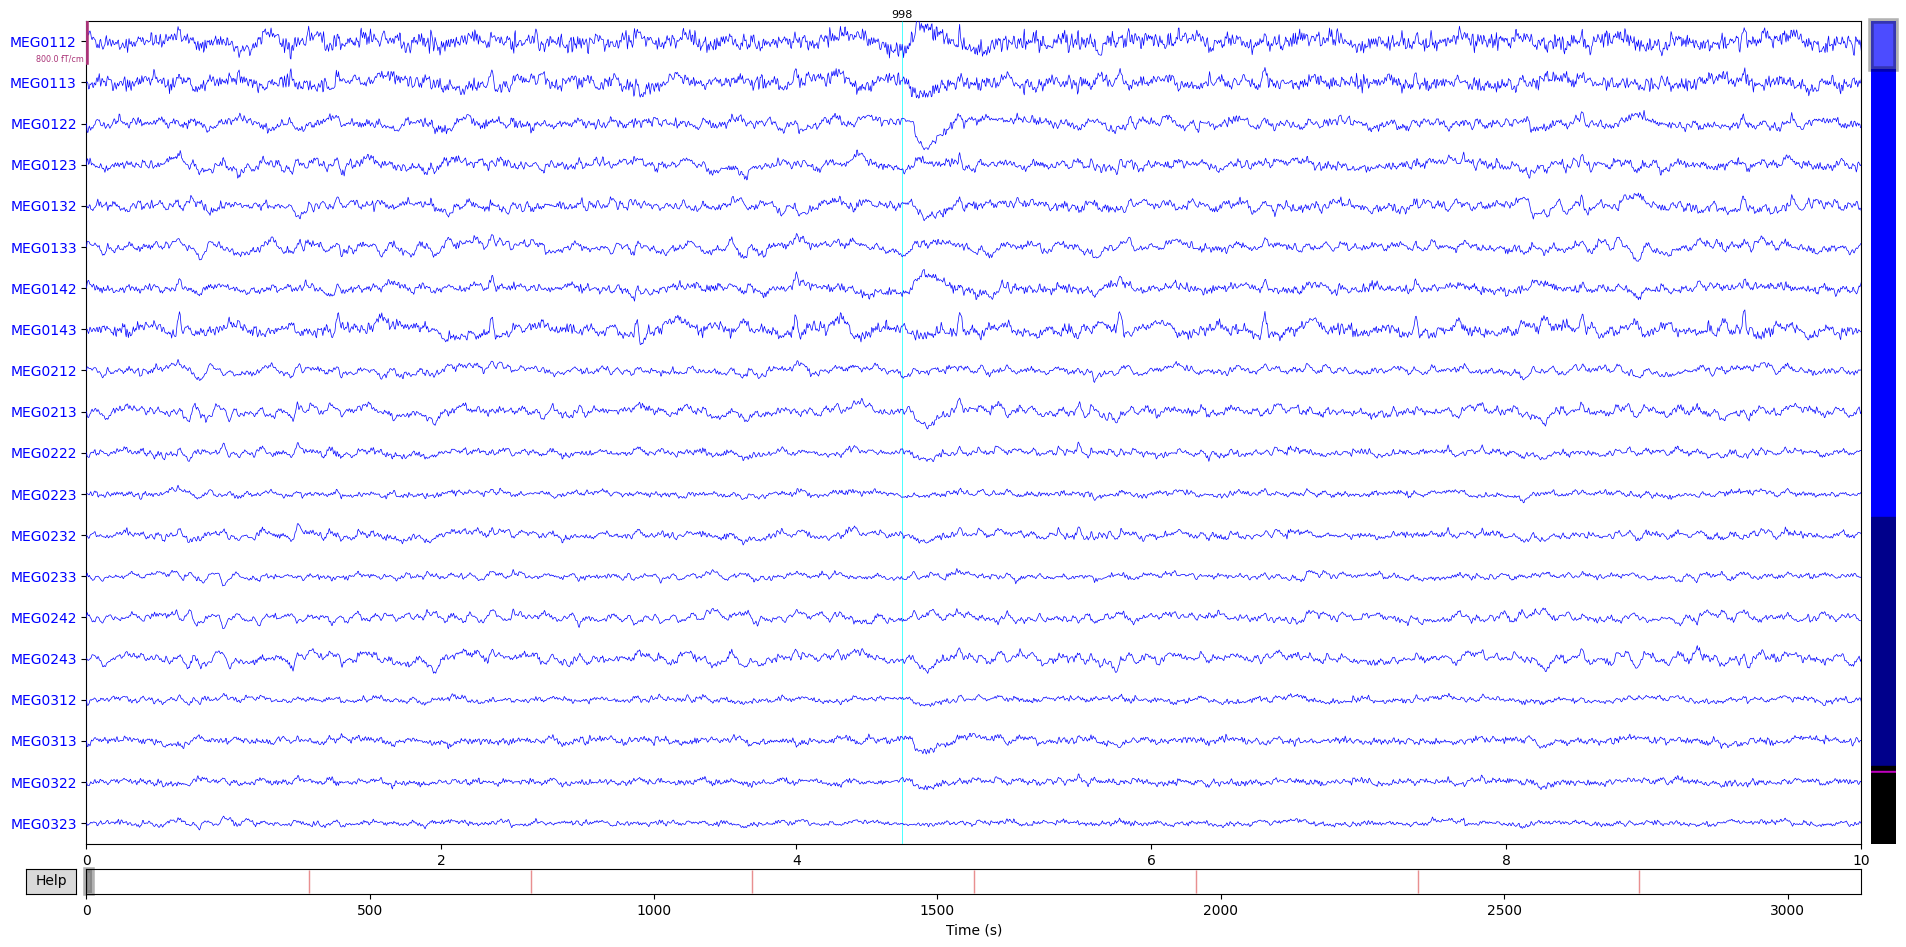

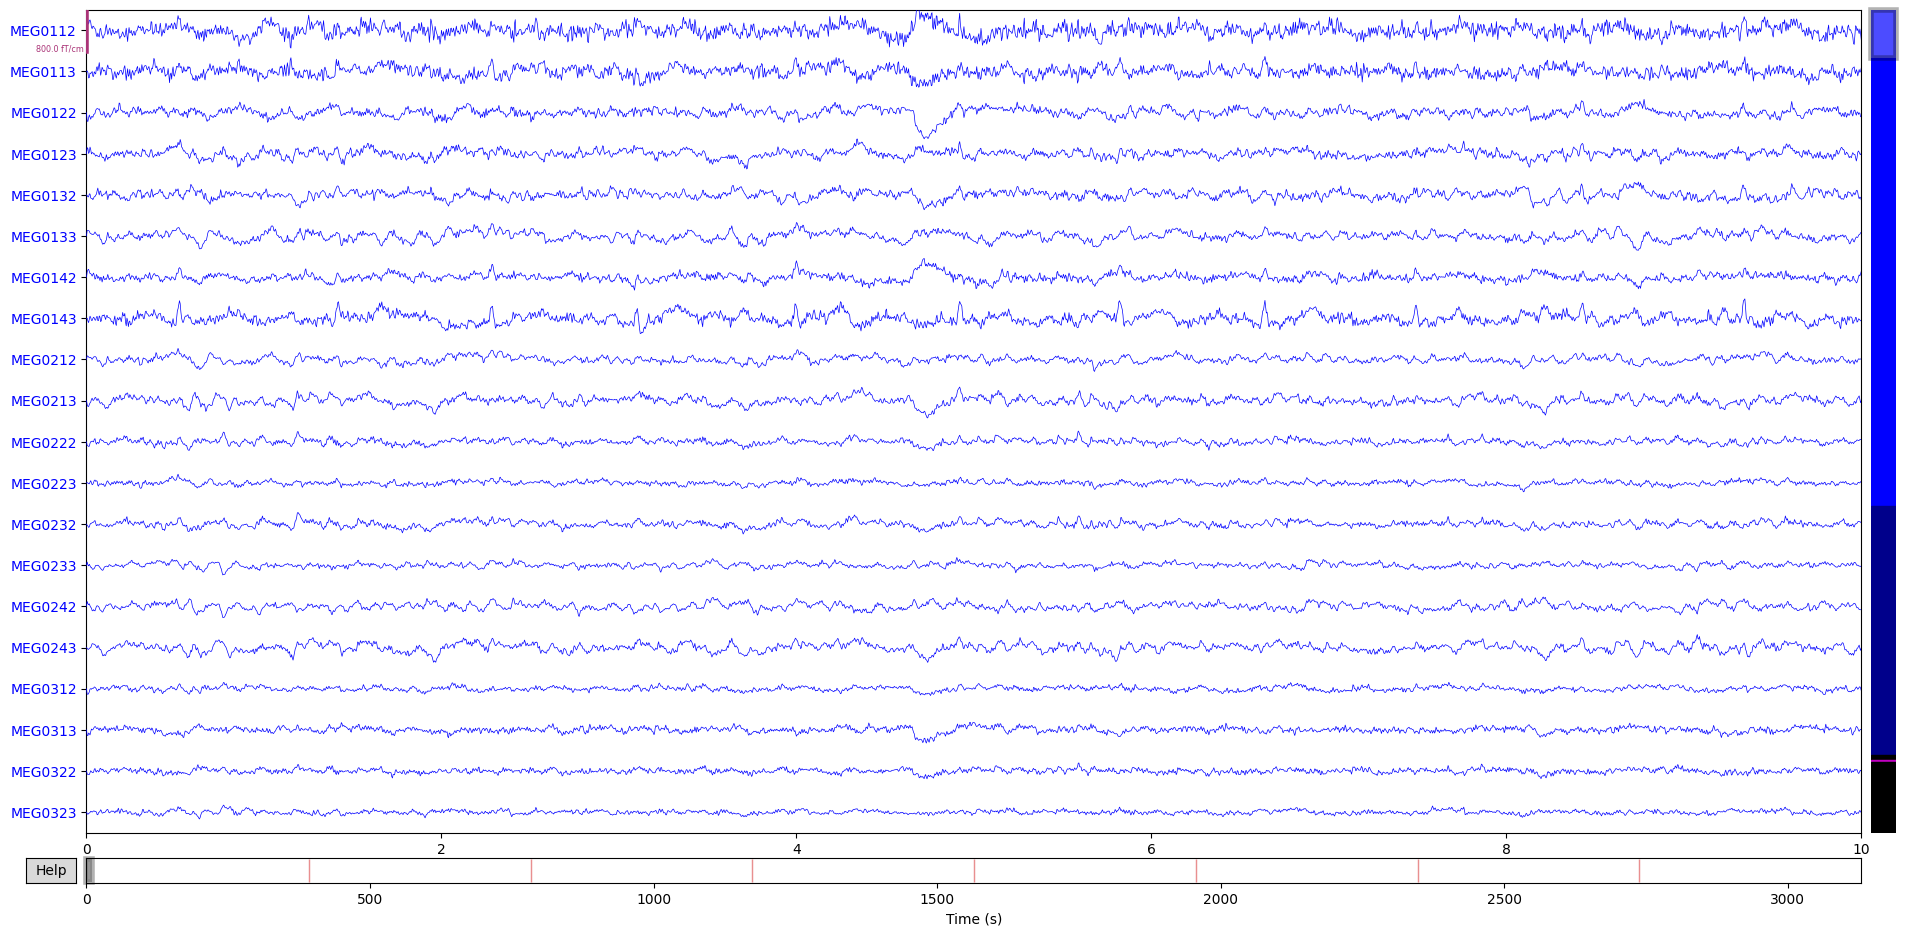

Fitting ICA to data using 306 channels (please be patient, this may take a while)


: 

In [8]:
# EOG annotation
eog_events = find_eog_events(raw)#, ch_name="BIO002") #Try ch_name="BIO002" if no EOG labeled
# n_blinks = len(eog_events)
# onsets = eog_events[:, 0] / raw.info['sfreq'] - 0.25
# durations = np.repeat(0.5, n_blinks)
# descriptions = ['BAD_blink'] * n_blinks
# orig_time = raw.info['meas_date']
# blink_annot = mne.Annotations(onsets, durations, descriptions, orig_time)
# raw.set_annotations(blink_annot)  # Need to change depends on subject!!!  + Bad_span_1sec + Bad_span_2sec
raw.plot(events=eog_events)
raw.plot()

ica_raw = ICA(n_components=30, max_iter="auto", random_state=97) #V4 trying variance
ica = ica_raw.copy()
ica.fit(raw, reject_by_annotation=True)

# We are not rejecting the eog and ecg in this stage. But we run this part just to check the ICs
# Now lets detect bad components -- define filter params for EOG detection
l_freq=0.5
h_freq=10

# Selecting comps for exclusion
ica.exclude = []
exclude_list = []

eog_indices, eog_scores = ica.find_bads_eog(raw, l_freq=l_freq, h_freq=h_freq)#, ch_name="BIO002") #added in freq range
ecg_indices, ecg_scores = ica.find_bads_ecg(raw)
musc_indices, musc_scores = ica.find_bads_muscle(raw)
ica.exclude =  eog_indices + ecg_indices #+ musc_indices 
exclude_list = eog_indices + ecg_indices #+ musc_indices 

# Plot time series of all the independant components 
# chosen components will be shown greyed out; you can see the chosen components resemble blinks & eye movements
ica.plot_sources(raw, picks=None, start=40, stop=60,show_scrollbars=True)

# Plot spatial patterns of ICs
fig = ica.plot_components()  # This line will generate the plot
                   
# Bar chart of ICA components - ICs that match EOG + ECG will be shown in RED
fig = ica.plot_scores(eog_scores)
fig.savefig(op.join(meg_dir, v,'figures','%s_IC_eog_scores.png' %s))
# Bar chart for ECG
fig = ica.plot_scores(ecg_scores)                 
fig.savefig(op.join(meg_dir, v, 'figures','%s_IC_ecg_scores.png' %s))          

# Display component properties. Properties include the topography,
# epochs image, ERP/ERF, power spectrum, and epoch variance.
#ica.plot_properties(raw, picks=ica.exclude)

# Plot topographic brain mapping of ICs
fig = ica.plot_components(show=False)  # This line will generate the plot
plt.show()  

# apply ICA once satisfied
tsss_ica = ica.apply(raw)

## Plotting individual ICA components
### If you want to save each individual component, please run part II (comment part I). Otherwise, please go Part I(comment part II)

In [1]:
## Part I: Plotting each component's properties without save the figures
#ica.plot_properties(raw, picks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]) 

## Part II: Plotting each component's properties and saving the figures
for i in range(ica.n_components_):
    # Plot the properties of each component
    fig = ica.plot_properties(raw, picks=[i])
    
    # Save the figure to the specified path
    save_path = op.join(meg_dir, v, 'figures', f'{s}_Component_0{i}.png')
    fig[0].savefig(save_path, dpi=300, bbox_inches="tight")

NameError: name 'ica' is not defined

In [ ]:
# Now We reject ICs manually, input the excluding ICs
ica.exclude = [0, 2, 17, 20, 21, 23, 25, 28]
exclude_list = ica.exclude

# plot time series of all the independant components 
# chosen components will be shown greyed out; you can see the chosen components resemble blinks & eye movements
ica.plot_sources(raw, picks=None, start=40, stop=60,show_scrollbars=True)

# plot spatial patterns of ICs
# Again, the second and third component are blinks & eye movements
fig = ica.plot_components()  # This line will generate the plot
                   
# barplot of ICA components - ICs that match EOG + ECG will be shown in RED
fig = ica.plot_scores(eog_scores)
# Define the save path
save_path = os.path.join(meg_dir, v, 'figures', f"{s}_IC_eog_scores_manual.png")

# Check if the file exists and delete it (optional but ensures overwrite)
if os.path.exists(save_path):
    os.remove(save_path)
# Save the figure without the overwrite argument
fig.savefig(save_path, dpi=300, bbox_inches="tight")


# repeat for ecg
fig = ica.plot_scores(ecg_scores)                 
# Define the save path
save_path = os.path.join(meg_dir, v, 'figures', f"{s}_IC_ecg_scores_manual.png")
# Check if the file exists and delete it (optional but ensures overwrite)
if os.path.exists(save_path):
    os.remove(save_path)
# Save the figure without the overwrite argument
fig.savefig(save_path, dpi=300, bbox_inches="tight")


# Display component properties. Properties include the topography,
#   epochs image, ERP/ERF, power spectrum, and epoch variance.
#ica.plot_properties(raw, picks=ica.exclude)

# plot spatial patterns of ICs
# Again, the second and third component are blinks & eye movements
fig = ica.plot_components(show=False)  # This line will generate the plot
plt.savefig(op.join(meg_dir, v, 'figures', '%s_ICs_patterns.png' %s)) #saving


# Retrieve all generated figures
fig_nums = plt.get_fignums()  # Get all figure numbers
for i, fig_num in enumerate(fig_nums):
    fig = plt.figure(fig_num)
    fig.savefig(os.path.join(meg_dir,v, 'figures', f'{s}_ICs_patterns_part{i+1}.png'), dpi=300, bbox_inches="tight")

plt.show()  # This line retrieves the current figure object

# Here we plot the data before and after excluding the bad artifacts (EOG/ECG/EMG) 
    # red and black signal thing. 
Gradiometer = ica.plot_overlay(raw, exclude=exclude_list, picks='grad')
Gradiometer.savefig(os.path.join(meg_dir,v, 'figures', f'{s}_Gradiometer_ICA_Overlay'), dpi=300)

Magnetometer = ica.plot_overlay(raw, exclude=exclude_list, picks='mag')
Magnetometer.savefig(os.path.join(meg_dir,v, 'figures', f'{s}_Magnetometer_ICA_Overlay'), dpi=300)

## For checking the Joint plots to see the ICA rejected data

In [ ]:
# Apply ICA to raw data, once staisfied
RAW_ICA = ica.copy().apply(raw, exclude=exclude_list)

# Make copy of events
adjusted_events = events_cleaned.copy()
# adjust triggers for visual delay
t_adjust= 10e-3 # 10 ms for new projectors
t_adj = int(np.round(t_adjust *raw.info['sfreq']))
adjusted_events[:,0] += t_adj

#reject mags and grads > 9000 fT, 4000 fT/cm
#reject = dict(mag=9000e-15, grad=4000e-13)

# epoch data w respect to event onset
epochs = mne.Epochs(raw, adjusted_events, event_id=event_id, tmin=-0.3, tmax=0.8, baseline=(-0.3, -0.05), reject=None, preload=True)  #-0,05  # change the time longer......  tmin=-0.45, tmax=0.5, 

# Filter to keep only MEG channels (exclude EEG, EOG, ECG, etc.)
epochs = epochs.copy().pick_types( meg=True, eeg=False, eog=False, ecg=False, stim=False, exclude='bads', chpi=False)


In [ ]:
# Average the epoched data and store it in a dictionary
conds = {}
for cond_name in event_id.keys():
    #if cond_name != 'key_press':  # Skip key press events if you don't want to average them
        conds[cond_name] = epochs[cond_name].average()

# Plot the averages with the condition name and save the plots
for cond_name, cond_data in conds.items():
    # Generate the plot(s)
    figures = cond_data.plot_joint(times='peaks', title=cond_name)

## Apply dropped components on raw data and save it

In [ ]:
# Apply ICA to raw data, once staisfied
raw_ICA = ica.apply(raw, exclude=exclude_list)

# Save cleaned data
raw_ICA.save(op.join(meg_dir, v, f'{s}_GABOR_esss_ica_reject.fif'), overwrite = True)

del raw_ICA

## Epoch Section

In [ ]:
# Load your raw MEG data
raw_1000Hz = mne.io.Raw(op.join(meg_dir, v, f'{s}_GABOR_esss_ica_reject.fif'), preload=True)
raw = raw_1000Hz.resample(500, npad = 'auto')

In [ ]:
# Make copy of events
adjusted_events = events_cleaned.copy()
# adjust triggers for visual delay
t_adjust= 10e-3 # 10 ms for new projectors
t_adj = int(np.round(t_adjust *raw.info['sfreq']))
adjusted_events[:,0] += t_adj

In [ ]:
#reject mags and grads > 9000 fT, 4000 fT/cm
#reject = dict(mag=9000e-15, grad=4000e-13)

# epoch data w respect to event onset
epochs = mne.Epochs(raw, adjusted_events, event_id=event_id, tmin=-0.3, tmax=0.8, baseline=(-0.3, -0.05), reject=None, preload=True, reject_by_annotation=False)  #-0,05  # change the time longer......  tmin=-0.45, tmax=0.5, 

# Filter to keep only MEG channels (exclude EEG, EOG, ECG, etc.)
epochs = epochs.copy().pick_types( meg=True, eeg=False, eog=False, ecg=False, stim=False, exclude='bads', chpi=False)

## 1-48Hz filtered Butterfly joint plots

In [ ]:
# # FILTER DATA TO 1-48 Hz for cleaner butterfly plots
# epochs_filtered = epochs.copy().filter(l_freq=1, h_freq=48, fir_design='firwin', 
#                                       filter_length='auto', l_trans_bandwidth='auto', h_trans_bandwidth='auto')

# conds_filtered = {}

# for cond_name in event_id.keys():
#     # Filtered averages (1-48 Hz) for butterfly plots
#     conds_filtered[cond_name] = epochs_filtered[cond_name].average()

In [ ]:
# # Plot the filtered averages (1-48 Hz) for cleaner butterfly plots
# for cond_name, cond_data in conds_filtered.items():
#     print(f"Plotting filtered (1-48 Hz) butterfly plot for {cond_name}")
    
#     # Method 1: Using plot_joint with filtered data
#     figures = cond_data.plot_joint(times='peaks', title=f'{cond_name} (1-48 Hz)')

## Plotting butterfly plots

In [ ]:
# Average the epoched data and store it in a dictionary
conds = {}
for cond_name in event_id.keys():
    #if cond_name != 'key_press':  # Skip key press events if you don't want to average them
        conds[cond_name] = epochs[cond_name].average()

# Plot the averages with the condition name and save the plots
for cond_name, cond_data in conds.items():
    # Generate the plot(s)
    figures = cond_data.plot_joint(times='peaks', title=cond_name)
    
    # If `figures` is a list, save each figure individually
    if isinstance(figures, list):
        for i, fig in enumerate(figures):
            file_path = op.join(meg_dir, v, 'figures' f'{cond_name}_epochs_{i}.png')
            fig.savefig(file_path)
    else:
        # In case `figures` is a single figure (not a list), save it directly
        file_path = op.join(meg_dir, v, 'figures' f'{cond_name}_epochs_.png')
        figures.savefig(file_path)

## Save Files

In [ ]:
# Averaged signal epoch
evoked = epochs.average(by_event_type=True)
mne.write_evokeds(op.join(meg_dir,v,'Evoked', f'{s}_epochs-ave.fif'), evoked, overwrite=True)

# Save the epoch
epochs.save(op.join(meg_dir, v,'Evoked', f'{s}_epochs-epo.fif'), overwrite=True)